# A four-cell sea-surface temperature sample

Fetch a tiny NOAA CoastWatch subset, inspect its units, and visualize the four
grid centers. This uses `usdata` v0.6 or newer and the optional pandas reader.

**Saved outputs are a recorded run.** The execution and source retrieval times
below identify the snapshot. NOAA may revise data; a future run can differ.
Run **Restart Kernel and Run All Cells** to reproduce the workflow, or change
the query cell to explore another small region and timestamp.

See [examples setup](https://usdata.dev/examples/) for the optional environment and execution commands.

In [1]:
from datetime import UTC, datetime

import pandas as pd
from IPython.display import Markdown, display

import usdata
from usdata import build_query, get
from usdata.fetch import fetch

pd.set_option("display.max_rows", 8)
pd.set_option("display.max_columns", 8)
print(f"Executed (UTC): {datetime.now(UTC).isoformat(timespec='seconds')}")
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-09T00:11:44+00:00
usdata 0.7.0; pandas 3.0.5


## 1. Select the input

Bounds are `(west, south, east, north)`. These coordinates select four ocean
grid centers at one analysis time. Keep exploratory subsets small; date-only
bounds mean midnight, whereas this dataset's analyses are at noon UTC.

In [2]:
dataset = get("noaa:coastwatch-sst")
query = build_query(
    bbox=(-80.08, 30.02, -80.02, 30.08),
    start="2024-05-06T12:00Z",
    end="2024-05-06T12:00Z",
    variables=["analysed_sst"],
)
items = fetch(dataset, query)
(item,) = items
frame = item.open(parse_dates=["time"])
display(frame.round({"latitude": 3, "longitude": 3, "analysed_sst": 3}))

,time,latitude,longitude,analysed_sst
0,2024-05-06 12:00:00+00:00,30.025,-80.075,26.85
1,2024-05-06 12:00:00+00:00,30.025,-80.025,26.99
2,2024-05-06 12:00:00+00:00,30.075,-80.075,26.78
3,2024-05-06 12:00:00+00:00,30.075,-80.025,26.95


## 2. Inspect units and provenance

ERDDAP's second CSV record contains units. The reader moves it into metadata
instead of treating it as an observation. Coordinates, measurements, and units
stay in their original scientific conventions; no unit conversion occurs.

In [3]:
units = frame.attrs["units"]
display(pd.Series(units, name="source units").to_frame())

,source units
time,UTC
latitude,degrees_north
longitude,degrees_east
analysed_sst,degree_C


In [4]:
for item in items:
    print(f"{item.asset.dataset_id}")
    print(f"Retrieved (UTC): {item.provenance.retrieved_at.isoformat()}")
    print(f"Bytes: {item.provenance.size}; cache hit: {item.from_cache}")
    print(f"Checksum: {item.provenance.checksum}")
    display(Markdown(f"[Source request](<{item.provenance.source_url}>)"))

noaa:coastwatch-sst
Retrieved (UTC): 2026-09-09T00:11:44.923930+00:00
Bytes: 261; cache hit: False
Checksum: sha256:161d5cd3383fb2a6601d298aedd07f16966a47742881204115a1361c5b2a9a2e


[Source request](<https://coastwatch.noaa.gov/erddap/griddap/noaacwBLENDEDsstDNDaily.csv?analysed_sst%5B(2024-05-06T12:00:00Z):1:(2024-05-06T12:00:00Z)%5D%5B(30.025):1:(30.075)%5D%5B(-80.075):1:(-80.025)%5D>)

## 3. Summarize and plot

This is an **unweighted mean of four nearby grid centers**, not a regional or
climate statistic. The axes show grid coordinates, not a projected map. The
color scale applies only to this small sample.

In [5]:
print(f"{len(frame)} cells; mean SST: {frame['analysed_sst'].mean():.2f} {units['analysed_sst']}")

4 cells; mean SST: 26.89 degree_C


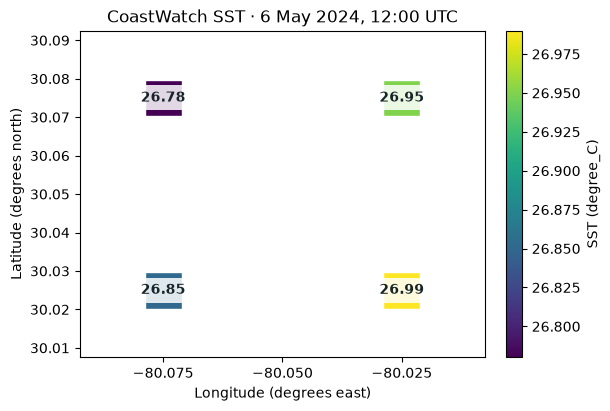

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=(6, 4), layout="constrained")
points = ax.scatter(
    frame["longitude"],
    frame["latitude"],
    c=frame["analysed_sst"],
    s=700,
    marker="s",
    cmap="viridis",
    edgecolors="white",
)
for row in frame.itertuples():
    ax.annotate(
        f"{row.analysed_sst:.2f}",
        (row.longitude, row.latitude),
        ha="center",
        va="center",
        color="#17252a",
        weight="bold",
        bbox={"facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
    )
ax.set(
    xlabel="Longitude (degrees east)",
    ylabel="Latitude (degrees north)",
    title="CoastWatch SST · 6 May 2024, 12:00 UTC",
)
ax.ticklabel_format(useOffset=False)
ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
ax.margins(0.35)
fig.colorbar(points, ax=ax, label=f"SST ({units['analysed_sst']})")
plt.show()

## 4. Reuse the cached input

Fetching the same query again validates and reuses the cached file. Editing
`frame` leaves the raw CSV and provenance untouched. For a persistent set of
pinned inputs, use a manifest as in the [monthly climate notebook](https://usdata.dev/examples/monthly-climate/).

In [7]:
(cached,) = fetch(dataset, query)
print(f"Second fetch used cache: {cached.from_cache}")
print(f"Same checksum: {cached.provenance.checksum == item.provenance.checksum}")

Second fetch used cache: True
Same checksum: True
